In [1]:
%%capture
!pip install pandas scikit-learn keras tensorflow
!pip install transformers torch
!pip install datasets


In [4]:
import torch
print(torch.cuda.is_available())


False


In [5]:
import pandas as pd
import numpy as np
import os, re
import matplotlib.pyplot as plt
import seaborn as sns

#Tamil

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


SVM with Combined Features Performance on Validation set
              precision    recall  f1-score   support

          AI       0.94      0.77      0.85        86
       HUMAN       0.78      0.95      0.86        76

    accuracy                           0.85       162
   macro avg       0.86      0.86      0.85       162
weighted avg       0.87      0.85      0.85       162

SVM with Combined Model Performance on Test set
              precision    recall  f1-score   support

          AI       0.75      0.79      0.77        48
       HUMAN       0.80      0.75      0.77        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



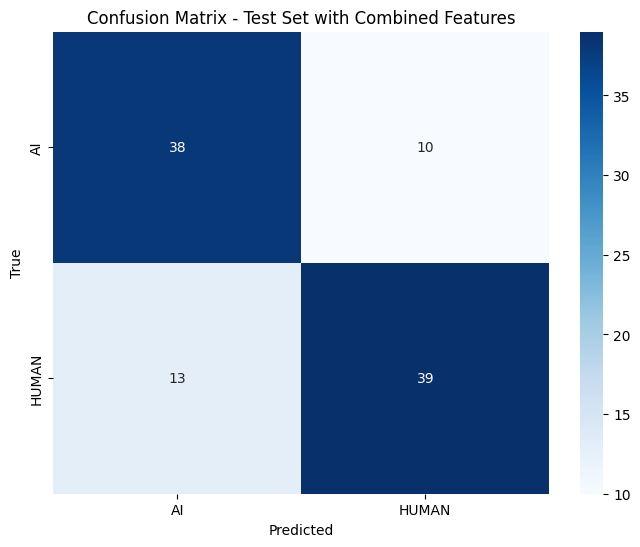

In [8]:
import pandas as pd
import numpy as np
import re
import nltk
nltk.download('punkt_tab')
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')

train_data = pd.read_csv('tam_train.csv')
test_data = pd.read_csv('tam_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_data['DATA'])
X_train_tfidf = vectorizer.transform(train_data['DATA']).toarray()

X_train_combined = np.hstack([X_train_tfidf, X_train_word2vec])

scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_combined)

X_train_final, X_val_combined, y_train, y_val = train_test_split(X_train_combined, train_data['LABEL'], test_size=0.2, random_state=42)

svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train_final, y_train)

y_pred_combined = svm_model.predict(X_val_combined)

y_pred_combined_labels = label_encoder.inverse_transform(y_pred_combined)

y_val_labels = label_encoder.inverse_transform(y_val)

print("SVM with Combined Features Performance on Validation set")
print(classification_report(y_val_labels, y_pred_combined_labels, target_names=label_encoder.classes_))

X_test_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in test_data['DATA']])
X_test_tfidf = vectorizer.transform(test_data['DATA']).toarray()
X_test_combined = np.hstack([X_test_tfidf, X_test_word2vec])
X_test_combined = scaler.transform(X_test_combined)

svm_predictions_combined = svm_model.predict(X_test_combined)

svm_predictions_combined_labels = label_encoder.inverse_transform(svm_predictions_combined)

test_data['LABEL_PRED'] = svm_predictions_combined_labels

test_data[["ID", "LABEL_PRED"]].to_csv('prediction_tam_svm.csv', index=False)

report_combined = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("SVM with Combined Model Performance on Test set")
print(report_combined)

conf_matrix_test_combined = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_combined, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with Combined Features")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'sigmoid'}
Best SVM Model Performance on Validation set
              precision    recall  f1-score   support

          AI       0.95      0.83      0.88        86
       HUMAN       0.83      0.95      0.88        76

    accuracy                           0.88       162
   macro avg       0.89      0.89      0.88       162
weighted avg       0.89      0.88      0.88       162

Best SVM Model Performance on Test set
              precision    recall  f1-score   support

          AI       0.71      0.77      0.74        48
       HUMAN       0.77      0.71      0.74        52

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100



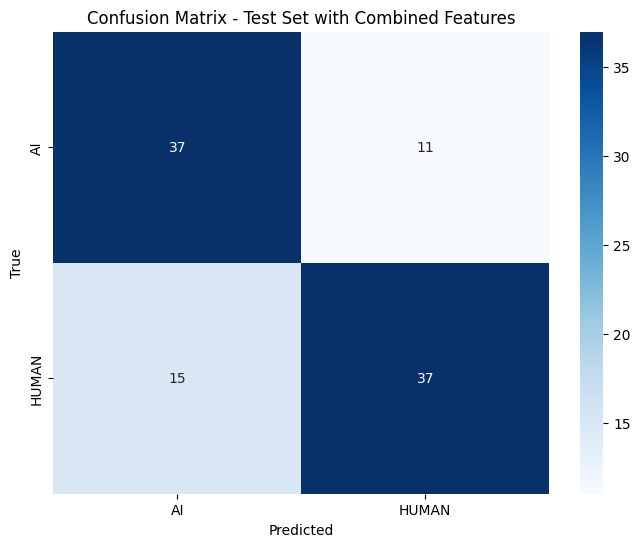

In [9]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')

train_data = pd.read_csv('tam_train.csv')
test_data = pd.read_csv('tam_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_data['DATA'])
X_train_tfidf = vectorizer.transform(train_data['DATA']).toarray()

X_train_combined = np.hstack([X_train_tfidf, X_train_word2vec])

scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_combined)

X_train_final, X_val_combined, y_train, y_val = train_test_split(X_train_combined, train_data['LABEL'], test_size=0.2, random_state=42)

param_grid = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_final, y_train)

print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

y_pred_combined = best_model.predict(X_val_combined)

y_pred_combined_labels = label_encoder.inverse_transform(y_pred_combined)

y_val_labels = label_encoder.inverse_transform(y_val)

print("Best SVM Model Performance on Validation set")
print(classification_report(y_val_labels, y_pred_combined_labels, target_names=label_encoder.classes_))

X_test_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in test_data['DATA']])
X_test_tfidf = vectorizer.transform(test_data['DATA']).toarray()
X_test_combined = np.hstack([X_test_tfidf, X_test_word2vec])
X_test_combined = scaler.transform(X_test_combined)

svm_predictions_combined = best_model.predict(X_test_combined)

svm_predictions_combined_labels = label_encoder.inverse_transform(svm_predictions_combined)

test_data['LABEL_PRED'] = svm_predictions_combined_labels

test_data[["ID", "LABEL_PRED"]].to_csv('prediction.csv', index=False)

report_combined = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("Best SVM Model Performance on Test set")
print(report_combined)

conf_matrix_test_combined = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_combined, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with Combined Features")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.5008 - loss: 0.6932 - val_accuracy: 0.6605 - val_loss: 0.6870
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.5651 - loss: 0.6855 - val_accuracy: 0.5556 - val_loss: 0.6813
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.5897 - loss: 0.6704 - val_accuracy: 0.6173 - val_loss: 0.6658
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.6763 - loss: 0.6029 - val_accuracy: 0.6543 - val_loss: 0.6353
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6908 - loss: 0.5857 - val_accuracy: 0.6481 - val_loss: 0.6346
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6856 - loss: 0.6023 - val_accuracy: 0.6358 - val_loss: 0.6272
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.6900 - loss: 0.6116 - val_accuracy: 0.6790 - val_loss: 0.6367
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.7023 - loss: 0.6054 - val_accuracy: 0.6481 -

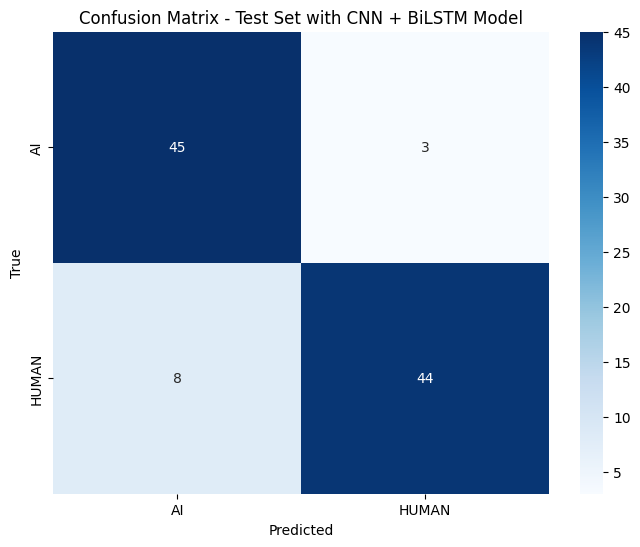

In [16]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('punkt')

train_data = pd.read_csv('tam_train.csv')
test_data = pd.read_csv('tam_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

tokenizer = keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(train_data['DATA'])
X_train_seq = tokenizer.texts_to_sequences(train_data['DATA'])
X_train_padded = pad_sequences(X_train_seq, maxlen=100)

y_train = train_data['LABEL'].values

X_train_final, X_val_seq, y_train, y_val = train_test_split(X_train_padded, y_train, test_size=0.2, random_state=42)

model = Sequential()

model.add(layers.Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(X_train_padded.shape[1], 1)))
model.add(layers.MaxPooling1D(pool_size=2))

model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))
model.add(layers.Dropout(0.5))

model.add(layers.GlobalAveragePooling1D())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(label_encoder.classes_), activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train_final, y_train, epochs=15, batch_size=32, validation_data=(X_val_seq, y_val))

y_pred_val = model.predict(X_val_seq)
y_pred_val_labels = np.argmax(y_pred_val, axis=1)

y_val_labels = label_encoder.inverse_transform(y_val)
y_pred_val_labels = label_encoder.inverse_transform(y_pred_val_labels)

print("CNN + BiLSTM Model Performance on Validation set")
print(classification_report(y_val_labels, y_pred_val_labels, target_names=label_encoder.classes_))

X_test_seq = tokenizer.texts_to_sequences(test_data['DATA'])
X_test_padded = pad_sequences(X_test_seq, maxlen=100)

y_pred_test = model.predict(X_test_padded)
y_pred_test_labels = np.argmax(y_pred_test, axis=1)
y_pred_test_labels = label_encoder.inverse_transform(y_pred_test_labels)

test_data['LABEL_PRED'] = y_pred_test_labels
test_data[["ID", "LABEL_PRED"]].to_csv('prediction.csv', index=False)

report_test = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("CNN + BiLSTM Model Performance on Test set")
print(report_test)

conf_matrix_test = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with CNN + BiLSTM Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5980 - loss: 0.6904 - val_accuracy: 0.7469 - val_loss: 0.6703
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9431 - loss: 0.6344 - val_accuracy: 0.8951 - val_loss: 0.5434
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9928 - loss: 0.4145 - val_accuracy: 0.9012 - val_loss: 0.3090
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 1.0000 - loss: 0.1166 - val_accuracy: 0.9012 - val_loss: 0.2111
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 1.0000 - loss: 0.0244 - val_accuracy: 0.9074 - val_loss: 0.1980
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 0.9074 - val_loss: 0.1997
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.9012 - val_loss: 0.2095
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9074 - val_loss: 0.

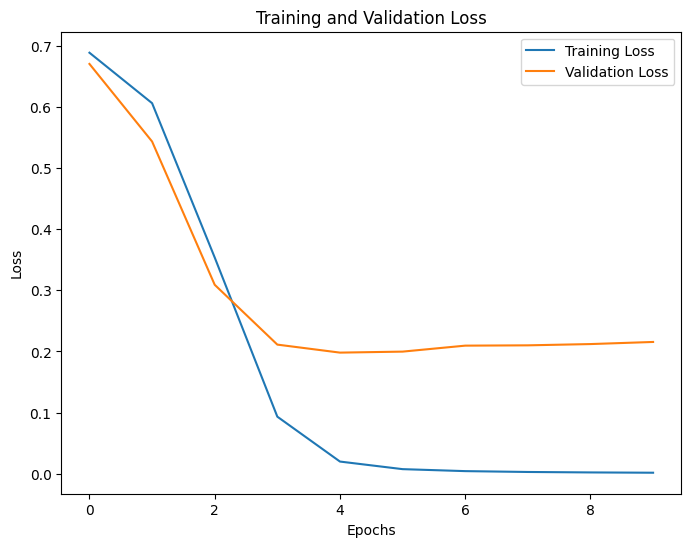

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MLP Model Performance on Validation set:
              precision    recall  f1-score   support

          AI       0.88      0.94      0.91        86
       HUMAN       0.93      0.86      0.89        76

    accuracy                           0.90       162
   macro avg       0.90      0.90      0.90       162
weighted avg       0.90      0.90      0.90       162

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MLP Model Performance on Test set:
              precision    recall  f1-score   support

          AI       0.73      0.73      0.73        48
       HUMAN       0.75      0.75      0.75        52

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100



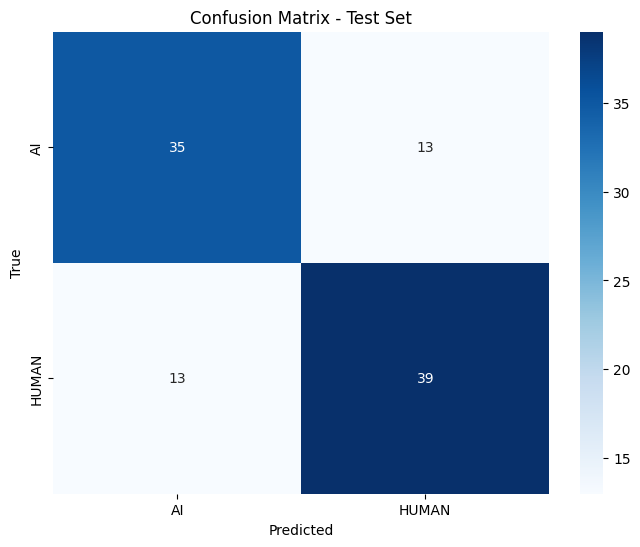

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

train_data = pd.read_csv('tam_train.csv')
test_data = pd.read_csv('tam_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X = train_data['DATA']
y = train_data['LABEL']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


vectorizer.fit(X_train)
X_train_vect = vectorizer.transform(X_train).toarray()
X_val_vect = vectorizer.transform(X_val).toarray()

mlp_model = keras.Sequential([
    layers.InputLayer(input_shape=(X_train_vect.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = mlp_model.fit(X_train_vect, y_train, epochs=10, batch_size=32, validation_data=(X_val_vect, y_val))

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

y_pred_mlp = (mlp_model.predict(X_val_vect) > 0.5).astype("int32")
print("MLP Model Performance on Validation set:")
print(classification_report(y_val, y_pred_mlp, target_names=label_encoder.classes_))


X_test = test_data['DATA']
X_test_vect = vectorizer.transform(X_test).toarray()

mlp_predictions = (mlp_model.predict(X_test_vect) > 0.5).astype("int32")
test_data['LABEL_PRED'] = label_encoder.inverse_transform(mlp_predictions.flatten())

test_data[["ID", "LABEL_PRED"]].to_csv('prediction.csv', index=False)

report = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("MLP Model Performance on Test set:")
print(report)

conf_matrix_test = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
!pip install scikit-learn==1.5.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 39.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Random Forest Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.86      0.69      0.76        86
       HUMAN       0.71      0.87      0.78        76

    accuracy                           0.77       162
   macro avg       0.78      0.78      0.77       162
weighted avg       0.79      0.77      0.77       162

XGBoost Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.82      0.80      0.81        86
       HUMAN       0.78      0.80      0.79        76

    accuracy                           0.80       162
   macro avg       0.80      0.80      0.80       162
weighted avg       0.80      0.80      0.80       162

Ensemble Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.82      0.76      0.79        86
       HUMAN       0.75      0.82      0.78        76

    accuracy                           0.78       162
   m

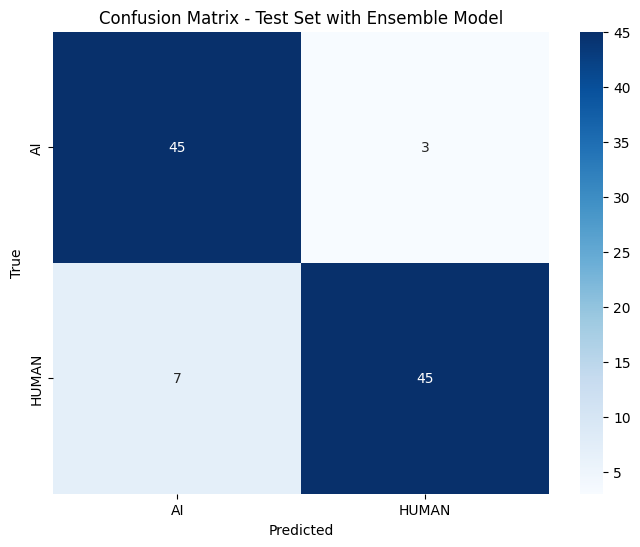

In [18]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('punkt_tab')

train_data = pd.read_csv('tam_train.csv')
test_data = pd.read_csv('tam_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_data['DATA'])
X_train_tfidf = vectorizer.transform(train_data['DATA']).toarray()

X_train_combined = np.hstack([X_train_tfidf, X_train_word2vec])

scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_combined)

X_train_final, X_val_combined, y_train, y_val = train_test_split(X_train_combined, train_data['LABEL'], test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=10, random_state=42)
xgb_model.fit(X_train_final, y_train)

ensemble_model = VotingClassifier(estimators=[('rf', rf_model), ('xgb', xgb_model)], voting='soft')
ensemble_model.fit(X_train_final, y_train)

y_val_labels = label_encoder.inverse_transform(y_val)

y_pred_rf = rf_model.predict(X_val_combined)
y_pred_rf_labels = label_encoder.inverse_transform(y_pred_rf)

y_pred_xgb = xgb_model.predict(X_val_combined)
y_pred_xgb_labels = label_encoder.inverse_transform(y_pred_xgb)

y_pred_ensemble = ensemble_model.predict(X_val_combined)
y_pred_ensemble_labels = label_encoder.inverse_transform(y_pred_ensemble)

print("Random Forest Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_rf_labels, target_names=label_encoder.classes_))

print("XGBoost Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_xgb_labels, target_names=label_encoder.classes_))

print("Ensemble Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_ensemble_labels, target_names=label_encoder.classes_))

X_test_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in test_data['DATA']])

X_test_tfidf = vectorizer.transform(test_data['DATA']).toarray()

X_test_combined = np.hstack([X_test_tfidf, X_test_word2vec])
X_test_combined = scaler.transform(X_test_combined)

predictions_ensemble = ensemble_model.predict(X_test_combined)
predictions_ensemble_labels = label_encoder.inverse_transform(predictions_ensemble)

test_data['LABEL_PRED'] = predictions_ensemble_labels
test_data[["ID", "LABEL_PRED"]].to_csv('prediction_tam_ensemble.csv', index=False)

report_ensemble = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("Ensemble (RF + XGBoost) Performance on Test Set")
print(report_ensemble)

conf_matrix_test_ensemble = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_ensemble, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with Ensemble Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()




---
#Malayalam


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'sigmoid'}
Best SVM Model Performance on Validation set
              precision    recall  f1-score   support

          AI       0.74      0.84      0.78        80
       HUMAN       0.81      0.70      0.75        80

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160

Best SVM Model Performance on Test set
              precision    recall  f1-score   support

          AI       0.67      0.59      0.63       100
       HUMAN       0.63      0.71      0.67       100

    accuracy                           0.65       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.65      0.65      0.65       200



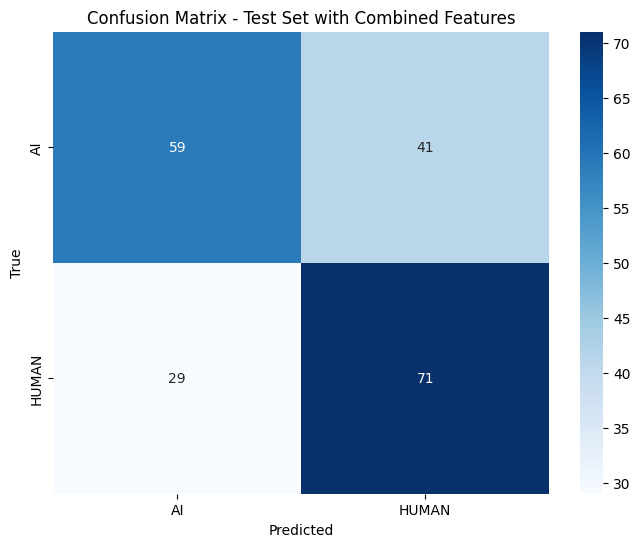

In [13]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')

train_data = pd.read_csv('mal_train.csv')
test_data = pd.read_csv('mal_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_data['DATA'])
X_train_tfidf = vectorizer.transform(train_data['DATA']).toarray()

X_train_combined = np.hstack([X_train_tfidf, X_train_word2vec])

scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_combined)

X_train_final, X_val_combined, y_train, y_val = train_test_split(X_train_combined, train_data['LABEL'], test_size=0.2, random_state=42)

param_grid = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_final, y_train)

print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

y_pred_combined = best_model.predict(X_val_combined)

y_pred_combined_labels = label_encoder.inverse_transform(y_pred_combined)

y_val_labels = label_encoder.inverse_transform(y_val)

print("Best SVM Model Performance on Validation set")
print(classification_report(y_val_labels, y_pred_combined_labels, target_names=label_encoder.classes_))

X_test_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in test_data['DATA']])
X_test_tfidf = vectorizer.transform(test_data['DATA']).toarray()
X_test_combined = np.hstack([X_test_tfidf, X_test_word2vec])
X_test_combined = scaler.transform(X_test_combined)

svm_predictions_combined = best_model.predict(X_test_combined)

svm_predictions_combined_labels = label_encoder.inverse_transform(svm_predictions_combined)

test_data['LABEL_PRED'] = svm_predictions_combined_labels

test_data[["ID", "LABEL_PRED"]].to_csv('prediction_mal_svm.csv', index=False)

report_combined = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("Best SVM Model Performance on Test set")
print(report_combined)

conf_matrix_test_combined = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_combined, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with Combined Features")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.4923 - loss: 0.6802 - val_accuracy: 0.7063 - val_loss: 0.6500
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5850 - loss: 0.6562 - val_accuracy: 0.6938 - val_loss: 0.6186
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.6739 - loss: 0.6129 - val_accuracy: 0.6687 - val_loss: 0.6171
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.5885 - loss: 0.6320 - val_accuracy: 0.7000 - val_loss: 0.5916
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.7217 - loss: 0.5873 - val_accuracy: 0.7188 - val_loss: 0.5607
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.6769 - loss: 0.5779 - val_accuracy: 0.7188 - val_loss: 0.5488
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.6810 - loss: 0.5797 - val_accuracy: 0.6875 - val_loss: 0.5382
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.6719 - loss: 0.5829 - val_accuracy: 0.7125 -

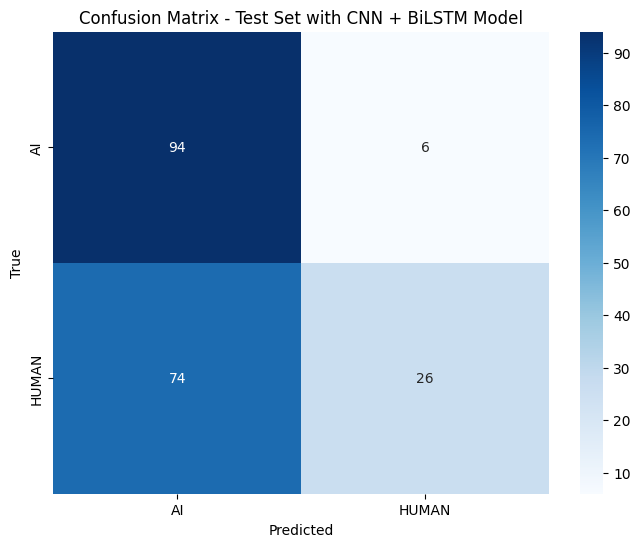

In [14]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('punkt')

train_data = pd.read_csv('mal_train.csv')
test_data = pd.read_csv('mal_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

tokenizer = keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(train_data['DATA'])
X_train_seq = tokenizer.texts_to_sequences(train_data['DATA'])
X_train_padded = pad_sequences(X_train_seq, maxlen=100)

y_train = train_data['LABEL'].values

X_train_final, X_val_seq, y_train, y_val = train_test_split(X_train_padded, y_train, test_size=0.2, random_state=42)

model = Sequential()

model.add(layers.Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(X_train_padded.shape[1], 1)))
model.add(layers.MaxPooling1D(pool_size=2))

model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))
model.add(layers.Dropout(0.5))

model.add(layers.GlobalAveragePooling1D())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(label_encoder.classes_), activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train_final, y_train, epochs=15, batch_size=32, validation_data=(X_val_seq, y_val))

y_pred_val = model.predict(X_val_seq)
y_pred_val_labels = np.argmax(y_pred_val, axis=1)

y_val_labels = label_encoder.inverse_transform(y_val)
y_pred_val_labels = label_encoder.inverse_transform(y_pred_val_labels)

print("CNN + BiLSTM Model Performance on Validation set")
print(classification_report(y_val_labels, y_pred_val_labels, target_names=label_encoder.classes_))

X_test_seq = tokenizer.texts_to_sequences(test_data['DATA'])
X_test_padded = pad_sequences(X_test_seq, maxlen=100)

y_pred_test = model.predict(X_test_padded)
y_pred_test_labels = np.argmax(y_pred_test, axis=1)
y_pred_test_labels = label_encoder.inverse_transform(y_pred_test_labels)

test_data['LABEL_PRED'] = y_pred_test_labels
test_data[["ID", "LABEL_PRED"]].to_csv('prediction_mal_cnn_bilstm.csv', index=False)

report_test = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("CNN + BiLSTM Model Performance on Test set")
print(report_test)

conf_matrix_test = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with CNN + BiLSTM Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Random Forest Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.68      0.75      0.71        80
       HUMAN       0.72      0.65      0.68        80

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160

XGBoost Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.68      0.74      0.71        80
       HUMAN       0.71      0.65      0.68        80

    accuracy                           0.69       160
   macro avg       0.70      0.69      0.69       160
weighted avg       0.70      0.69      0.69       160

Ensemble (RF + XGBoost) Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.68      0.75      0.71        80
       HUMAN       0.72      0.65      0.68        80

    accuracy                           0.70

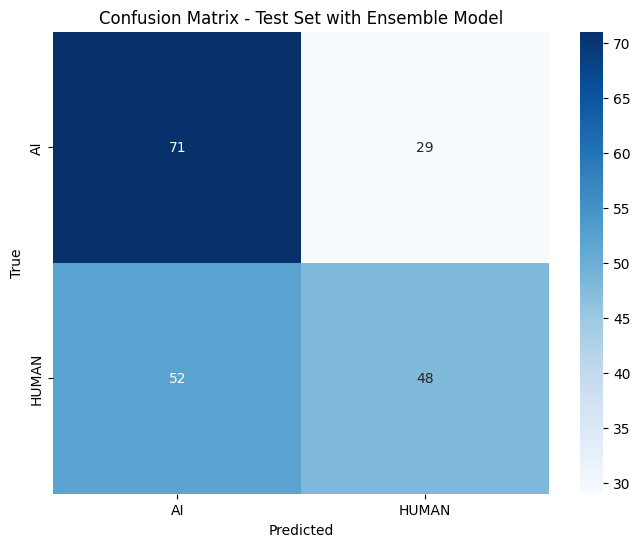

In [19]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('punkt_tab')

train_data = pd.read_csv('mal_train.csv')
test_data = pd.read_csv('mal_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_data['DATA'])
X_train_tfidf = vectorizer.transform(train_data['DATA']).toarray()

X_train_combined = np.hstack([X_train_tfidf, X_train_word2vec])

scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_combined)

X_train_final, X_val_combined, y_train, y_val = train_test_split(X_train_combined, train_data['LABEL'], test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=10, random_state=42)
xgb_model.fit(X_train_final, y_train)

ensemble_model = VotingClassifier(estimators=[('rf', rf_model), ('xgb', xgb_model)], voting='soft')
ensemble_model.fit(X_train_final, y_train)

y_val_labels = label_encoder.inverse_transform(y_val)

y_pred_rf = rf_model.predict(X_val_combined)
y_pred_rf_labels = label_encoder.inverse_transform(y_pred_rf)

y_pred_xgb = xgb_model.predict(X_val_combined)
y_pred_xgb_labels = label_encoder.inverse_transform(y_pred_xgb)

y_pred_ensemble = ensemble_model.predict(X_val_combined)
y_pred_ensemble_labels = label_encoder.inverse_transform(y_pred_ensemble)

print("Random Forest Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_rf_labels, target_names=label_encoder.classes_))

print("XGBoost Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_xgb_labels, target_names=label_encoder.classes_))

print("Ensemble (RF + XGBoost) Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_ensemble_labels, target_names=label_encoder.classes_))

X_test_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in test_data['DATA']])

X_test_tfidf = vectorizer.transform(test_data['DATA']).toarray()

X_test_combined = np.hstack([X_test_tfidf, X_test_word2vec])
X_test_combined = scaler.transform(X_test_combined)

predictions_ensemble = ensemble_model.predict(X_test_combined)
predictions_ensemble_labels = label_encoder.inverse_transform(predictions_ensemble)

test_data['LABEL_PRED'] = predictions_ensemble_labels
test_data[["ID", "LABEL_PRED"]].to_csv('prediction_mal_ensemble.csv', index=False)

report_ensemble = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("Ensemble Performance on Test Set")
print(report_ensemble)

conf_matrix_test_ensemble = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_ensemble, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with Ensemble Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()